<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [3]:
# Checking ConvertedCompYearly column
df["ConvertedCompYearly"].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [4]:
# Checking missing values
df["ConvertedCompYearly"].isna().sum()

np.int64(42002)

In [5]:
# Creating a new dataframe excluding missing values
compensation = df["ConvertedCompYearly"].dropna()

# Printing stats
print(f"Original rows: {len(df):,}")
print(f"Missing compensation: {df['ConvertedCompYearly'].isna().sum():,}")
print(f"Valid compensation values: {len(compensation):,}")

Original rows: 65,437
Missing compensation: 42,002
Valid compensation values: 23,435

In [6]:
# Missing values percentage
missing_pct = df["ConvertedCompYearly"].isna().mean() * 100

print(f"Missing compensation: {missing_pct:.2f}%")

Missing compensation: 64.19%

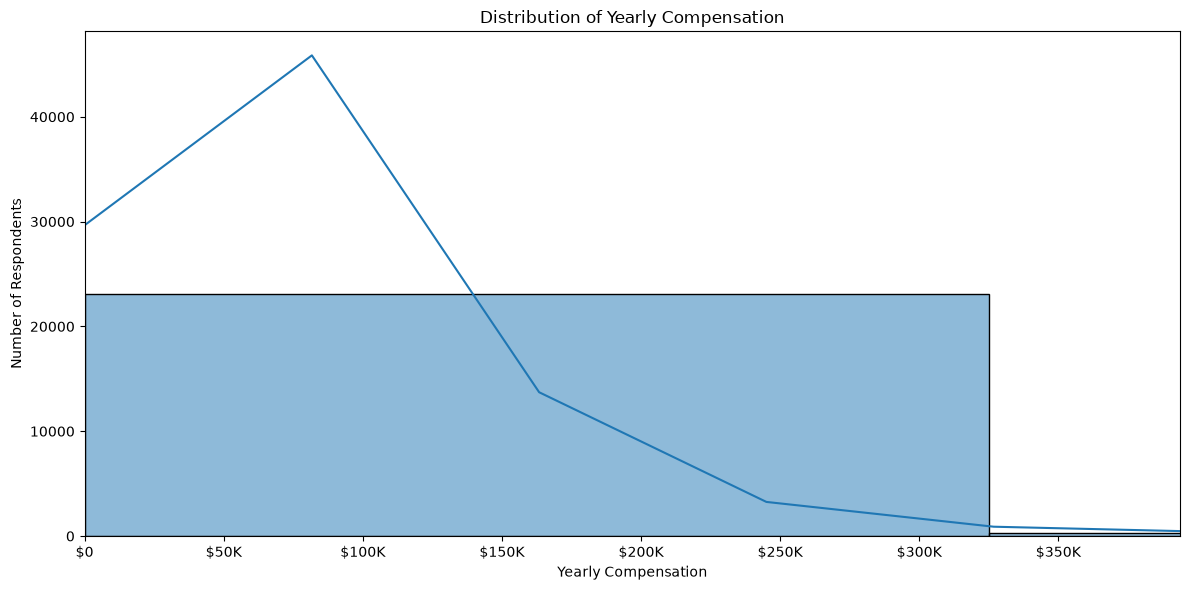

In [10]:
# Plotting the histogram based on compensation (without missing values)
from matplotlib.ticker import FuncFormatter

# Function to format the x labels like 30k 100k 500k 1M 15M values
def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

# Determine the 99th percentile
upper_limit = compensation.quantile(0.99)

plt.figure(figsize=(12, 6))

sns.histplot(
    compensation,
    bins=50,
    kde=True
)

# Zoom to the 99th percentile
plt.xlim(0, upper_limit)

plt.title("Distribution of Yearly Compensation")
plt.xlabel("Yearly Compensation")
plt.ylabel("Number of Respondents")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [16]:
# Filtering full-time employees excluding missing values on ConvertedCompYearly
full_time_compensation = df.loc[
    (df["Employment"] == "Employed, full-time") &
    (df["ConvertedCompYearly"].notna()),
    "ConvertedCompYearly"
]

median_compensation = full_time_compensation.median()

print(f"Full-time respondents with compensation: {len(full_time_compensation):,}")
print(f"Median compensation: ${median_compensation:,.2f}")

Full-time respondents with compensation: 17,586
Median compensation: $69,814.00

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [19]:
# Let's removing the missing values from both columns and add to a new dataframe
comp_country = df[
    ["Country", "ConvertedCompYearly"]
].dropna()

# Let's check the number of respondents per country
country_counts = comp_country["Country"].value_counts()
print(country_counts.head(20))

Country
United States of America                                4677
Germany                                                 2046
Ukraine                                                 1474
United Kingdom of Great Britain and Northern Ireland    1391
India                                                   1037
France                                                   918
Canada                                                   871
Brazil                                                   685
Poland                                                   586
Netherlands                                              561
Spain                                                    559
Italy                                                    540
Australia                                                510
Sweden                                                   457
Switzerland                                              386
Austria                                                  344
Czech Republic  

In [21]:
# As there're many countries let's filter the top 10 countries
top_countries = country_counts.head(10).index

comp_country_top = comp_country[
    comp_country["Country"].isin(top_countries)
]

top_countries

Index(['United States of America', 'Germany', 'Ukraine',
       'United Kingdom of Great Britain and Northern Ireland', 'India',
       'France', 'Canada', 'Brazil', 'Poland', 'Netherlands'],
      dtype='str', name='Country')

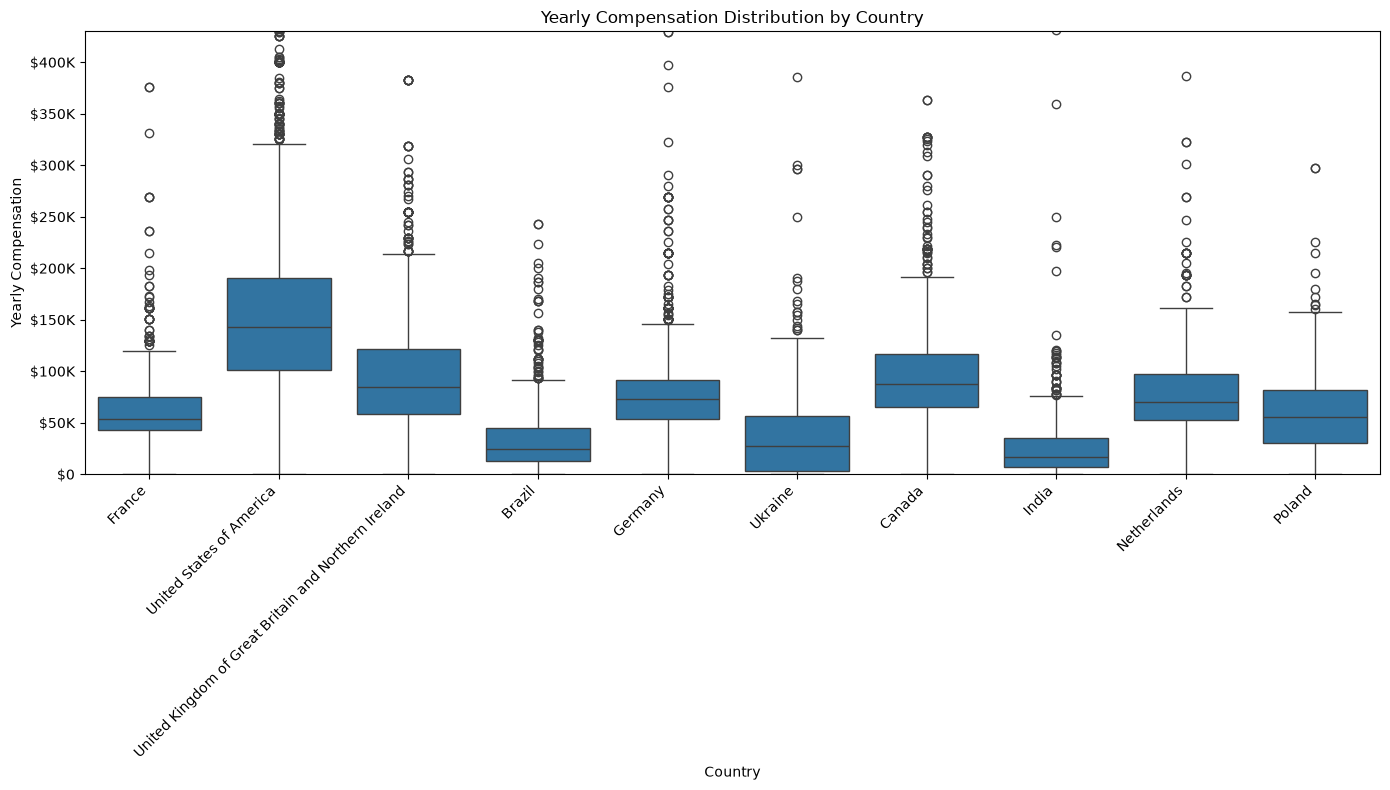

In [23]:
# Creating a boxplot chart based on top 10 contries zoomed 99th percentile
upper_limit = comp_country_top["ConvertedCompYearly"].quantile(0.99)

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=comp_country_top,
    x="Country",
    y="ConvertedCompYearly"
)

plt.ylim(0, upper_limit)

plt.title("Yearly Compensation Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Yearly Compensation")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

In [24]:
# Let's generate a new boxplot based on a minimum number of respondents
country_counts = comp_country["Country"].value_counts()

# Only countries with at least 100 valid compensation responses are included
countries = country_counts[country_counts >= 100].index

comp_country_filtered = comp_country[
    comp_country["Country"].isin(countries)
]

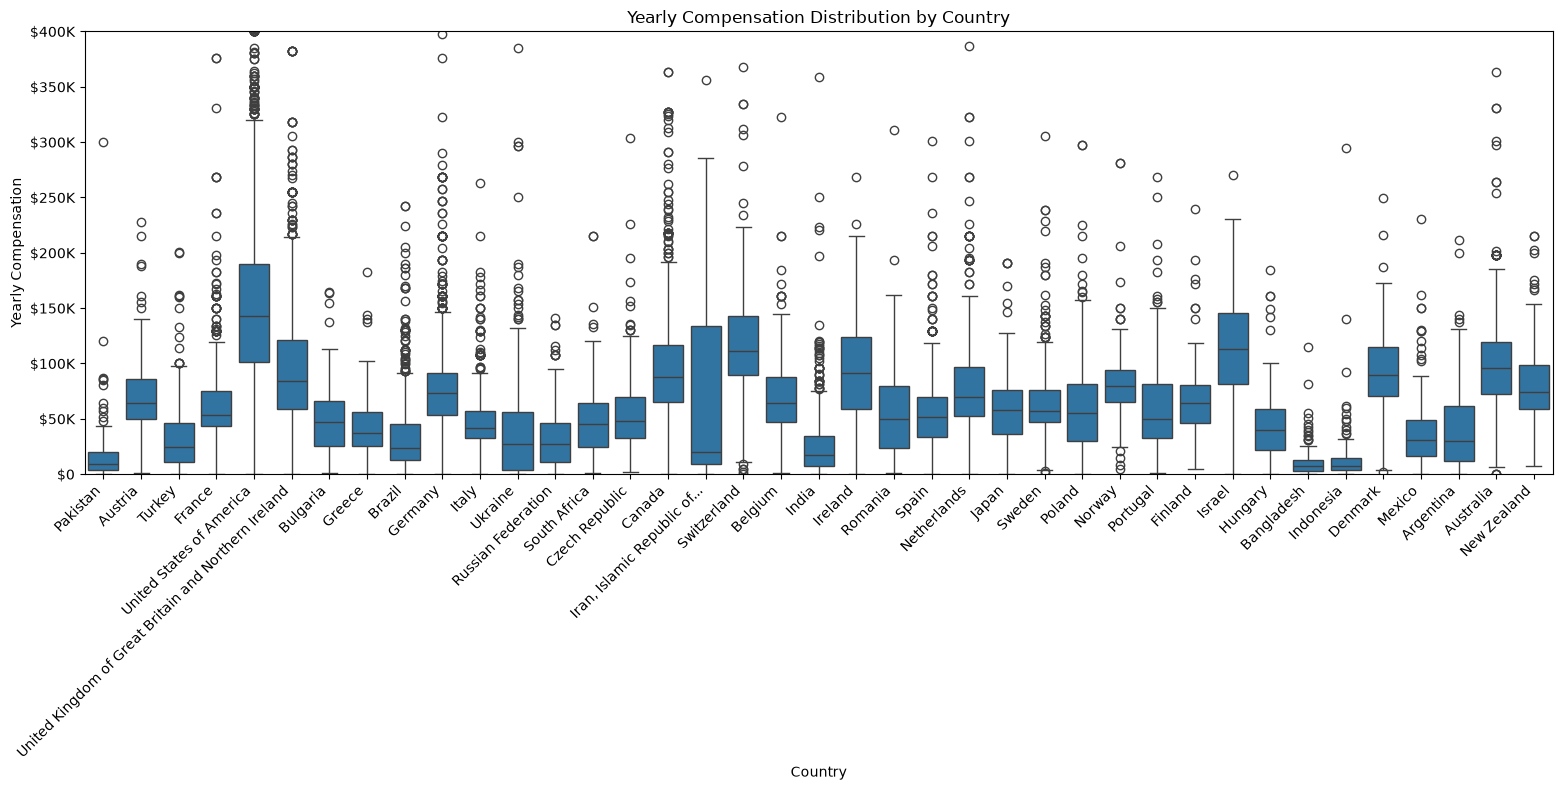

In [25]:
# Generting new boxplot
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=comp_country_filtered,
    x="Country",
    y="ConvertedCompYearly"
)

plt.ylim(
    0,
    comp_country_filtered["ConvertedCompYearly"].quantile(0.99)
)

plt.title("Yearly Compensation Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Yearly Compensation")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [26]:
# Calculate the IQR
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")

Q1: $32,712.00
Q3: $107,971.50
IQR: $75,259.50

In [27]:
# Calculate the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

Lower bound: $-80,177.25
Upper bound: $220,860.75

In [28]:
# Create the refined DataFrame
df_clean = df[
    (df["ConvertedCompYearly"] >= lower_bound) &
    (df["ConvertedCompYearly"] <= upper_bound)
].copy()

In [30]:
# Validating rows removal
removed_pct = (len(df) - len(df_clean)) / len(df) * 100

print(f"Original rows: {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")
print(f"Percentage of rows removed: {removed_pct:.2f}%")

Original rows: 65,437
Cleaned rows: 22,457
Rows removed: 42,980
Percentage of rows removed: 65.68%

In [31]:
# Checking if no outliers remain
remaining_outliers = df_clean[
    (df_clean["ConvertedCompYearly"] < lower_bound) |
    (df_clean["ConvertedCompYearly"] > upper_bound)
]

print(f"Remaining outliers: {len(remaining_outliers)}")

Remaining outliers: 0

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [32]:
# Selecting the three variables
correlation_data = df_clean[
    ["ConvertedCompYearly", "WorkExp", "JobSatPoints_1"]
]

In [35]:
# Correlation can't be calculaed with missing values let's clean up
correlation_data = correlation_data.dropna()

# Checking if it's cleaned
print(correlation_data.isna().sum())

ConvertedCompYearly    0
WorkExp                0
JobSatPoints_1         0
dtype: int64

In [36]:
# Calculating the correlation Matrix
correlation_matrix = correlation_data.corr()
correlation_matrix

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.406993,-0.059643
WorkExp,0.406993,1.000000,-0.032388
JobSatPoints_1,-0.059643,-0.032388,1.000000


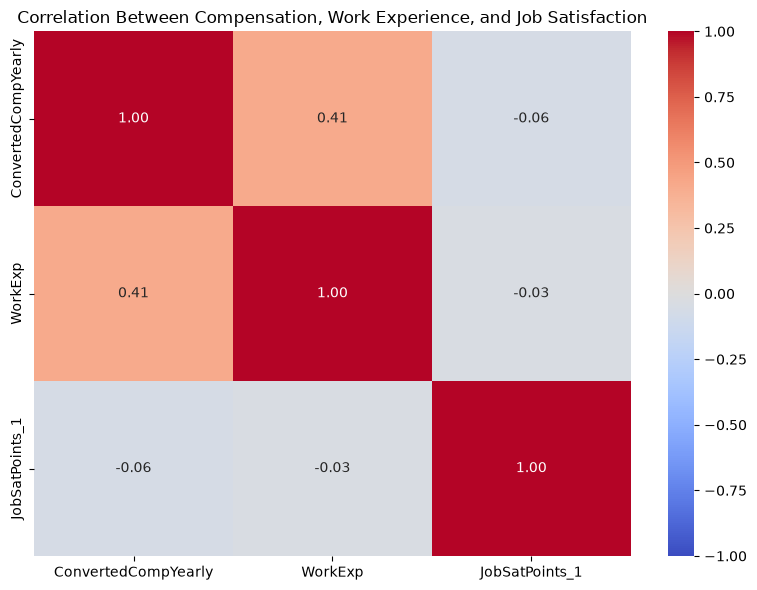

In [37]:
# Visualizing with a heatmap chart
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Between Compensation, Work Experience, and Job Satisfaction")
plt.tight_layout()
plt.show()

**Conclusion:** The analysis shows a moderate positive correlation (r = 0.41) between work experience and yearly compensation, suggesting that compensation tends to increase with experience. In contrast, yearly compensation and job satisfaction show a very weak negative correlation (r = -0.06), while work experience and job satisfaction have almost no correlation (r = -0.03). Overall, work experience appears more strongly associated with compensation than with job satisfaction

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


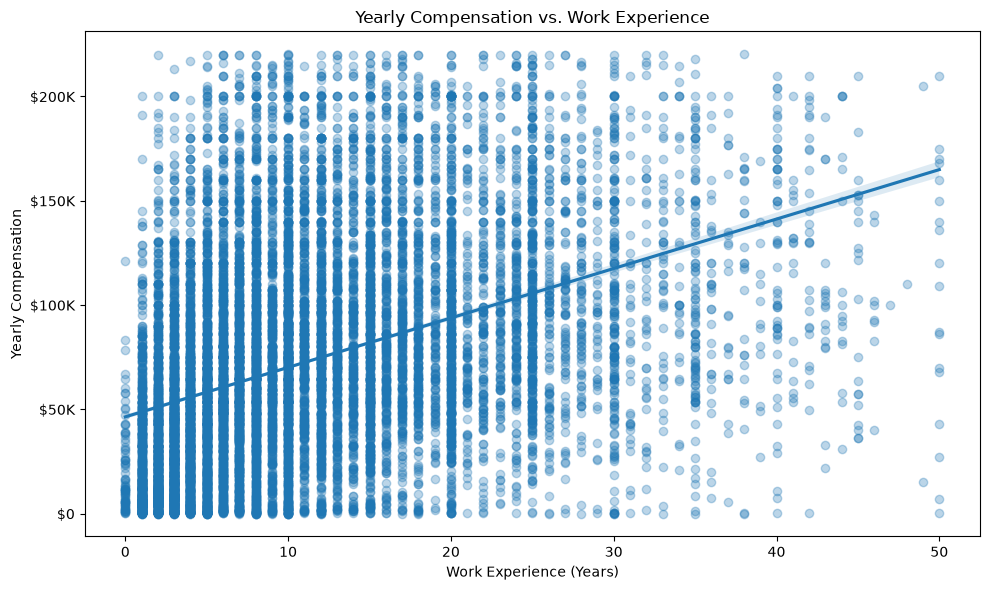

In [41]:
# Creating scatterplots visualization for correlation Conpensation vs Work Experience
plt.figure(figsize=(10, 6))

sns.regplot(
    data=correlation_data,
    x="WorkExp",
    y="ConvertedCompYearly",
    scatter_kws={"alpha": 0.3},
    line_kws={}
)

plt.title("Yearly Compensation vs. Work Experience")
plt.xlabel("Work Experience (Years)")
plt.ylabel("Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

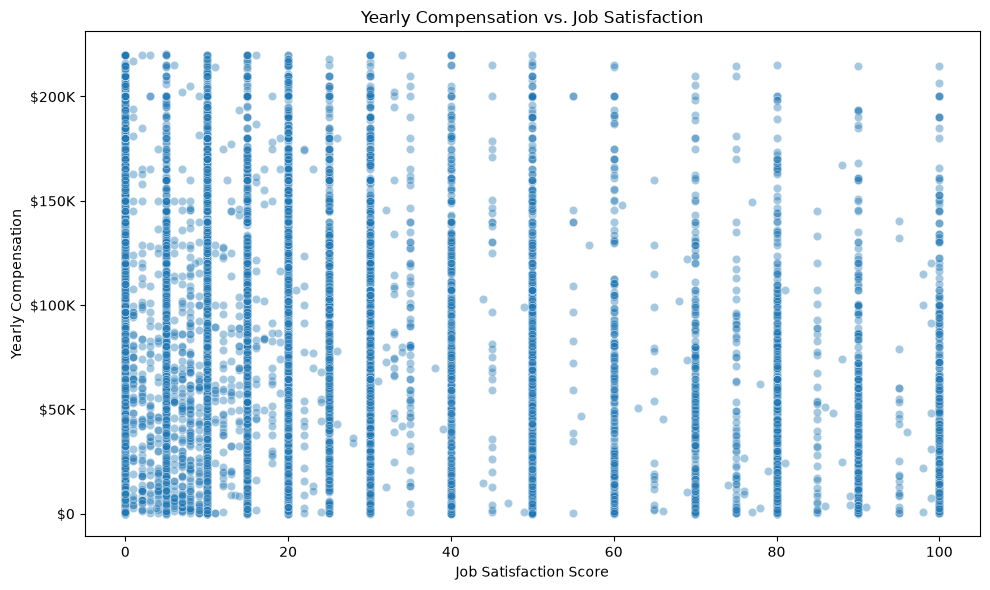

In [43]:
# Creating scatterplots visualization for correlation Conpensation vs Job Satisfaction
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=correlation_data,
    x="JobSatPoints_1",
    y="ConvertedCompYearly",
    alpha=0.4
)

plt.title("Yearly Compensation vs. Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
